# Comparativa de Modelos de Detección de IA (Versión Corregida)

Este notebook realiza una comparativa entre varios modelos de Hugging Face para detectar imágenes generadas por IA. 

### Cambios realizados:
1. **Modelos no restringidos**: He eliminado los modelos 'gated' (que requieren login) para evitar errores 401.
2. **Descarga robusta**: Mejora en la descarga de imágenes para evitar bloqueos de servidores.
3. **Manejo de errores**: Si una imagen no se puede identificar, el sistema informa por qué.

In [18]:
from transformers import pipeline
from PIL import Image
import torch
import requests
import io
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print(f"CUDA disponible: {torch.cuda.is_available()}")
device = 0 if torch.cuda.is_available() else -1

CUDA disponible: False


## 1. Configuración de Modelos

Cargamos modelos que son de acceso libre y no requieren token de Hugging Face.

In [19]:
models_to_test = [
    {"name": "umm-maybe/AI-image-detector", "label": "Current Baseline"},
    {"name": "Organika/sdxl-detector", "label": "SDXL Specialized"},
    {"name": "prithivMLmods/Deep-Fake-Detector-v2-Model", "label": "Deep-Fake V2"},
    {"name": "Nahid/AI_OR_REAL_Detector", "label": "AI vs Real General"}
]

detectors = {}

for m in models_to_test:
    print(f"Cargando {m['name']}...")
    try:
        detectors[m['name']] = pipeline("image-classification", model=m['name'], device=device)
        print(f"OK: {m['name']} cargado.")
    except Exception as e:
        print(f"ERROR cargando {m['name']}: {e}")

Cargando umm-maybe/AI-image-detector...


Loading weights: 100%|██████████| 449/449 [00:00<00:00, 7035.87it/s]


OK: umm-maybe/AI-image-detector cargado.
Cargando Organika/sdxl-detector...


Loading weights: 100%|██████████| 449/449 [00:00<00:00, 2852.44it/s]


OK: Organika/sdxl-detector cargado.
Cargando prithivMLmods/Deep-Fake-Detector-v2-Model...


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 2780.47it/s]


OK: prithivMLmods/Deep-Fake-Detector-v2-Model cargado.
Cargando Nahid/AI_OR_REAL_Detector...
ERROR cargando Nahid/AI_OR_REAL_Detector: Nahid/AI_OR_REAL_Detector is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`


In [20]:
def get_ai_score(results):
    """Extrae la probabilidad de que la imagen sea IA basándose en etiquetas comunes."""
    ai_labels = ['ai', 'fake', 'artificial', 'generated', 'LABEL_1', 'deepfake']
    real_labels = ['real', 'LABEL_0', 'human', 'authentic']
    
    # Primero buscar etiquetas explícitas de IA
    for res in results:
        label = res['label'].lower()
        if any(ai_tag in label for ai_tag in ai_labels):
            return res['score'] * 100
    
    # Si no hay IA, buscar de REAL y calcular el opuesto
    for res in results:
        label = res['label'].lower()
        if any(real_tag in label for real_tag in real_labels):
            return (1 - res['score']) * 100
            
    return 0

## 2. Función de Comparativa

In [21]:
def load_image(source):
    """Carga una imagen desde URL o ruta local de forma robusta."""
    if source.startswith('http'):
        headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36"
        }
        try:
            response = requests.get(source, headers=headers, timeout=10)
            response.raise_for_status()
            return Image.open(io.BytesIO(response.content)).convert("RGB")
        except Exception as e:
            print(f"Error al descargar/abrir la URL: {e}")
            return None
    else:
        try:
            return Image.open(source).convert("RGB")
        except Exception as e:
            print(f"Error al abrir archivo local: {e}")
            return None

def compare_models(image_source):
    img = load_image(image_source)
    if img is None:
        return None
    
    results_list = []
    
    for model_name, pipe in detectors.items():
        try:
            raw_results = pipe(img)
            score = get_ai_score(raw_results)
            results_list.append({
                "Model": model_name,
                "AI Probability (%)": round(score, 2),
                "Top Label": raw_results[0]['label']
            })
        except Exception as e:
            results_list.append({"Model": model_name, "AI Probability (%)": "Error", "Top Label": str(e)})
            
    df = pd.DataFrame(results_list)
    
    # Visualización de la imagen
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Imagen Analizada")
    plt.show()
    
    return df

## 3. Ejecución de Pruebas

Prueba con una imagen conocida para verificar que todo funciona.

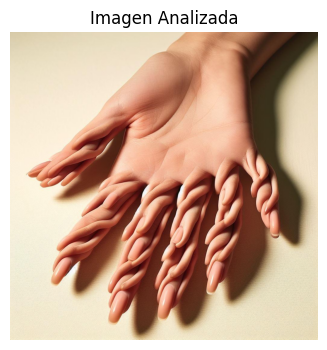

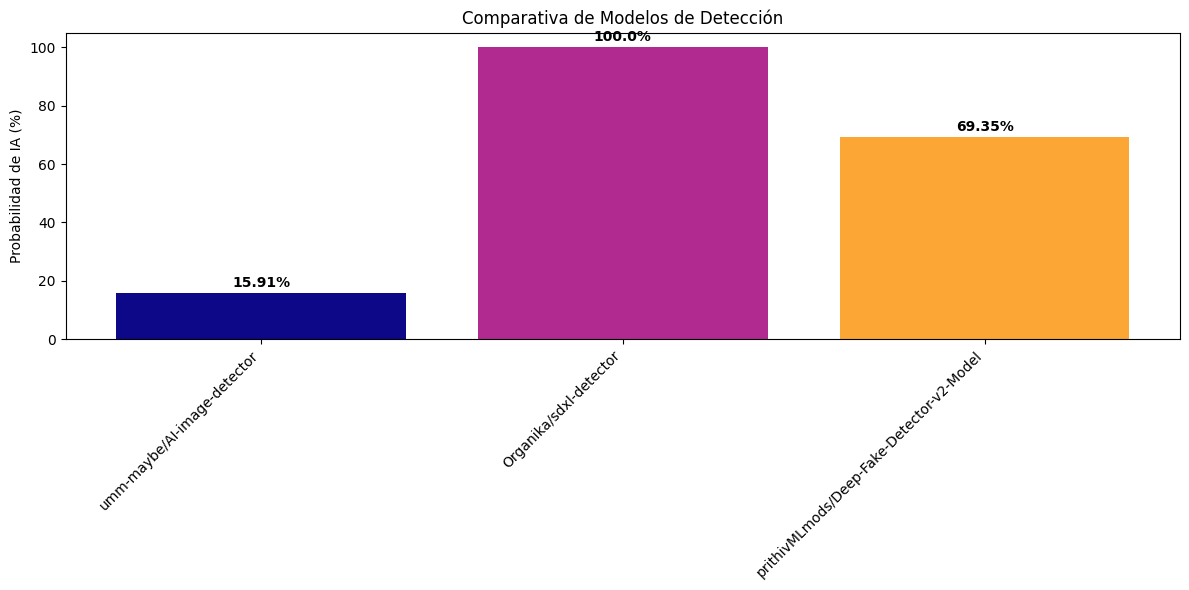

,Model,AI Probability (%),Top Label
0,umm-maybe/AI-image-detector,15.91,human
1,Organika/sdxl-detector,100.00,artificial
2,prithivMLmods/Deep-Fake-Detector-v2-Model,69.35,Deepfake


In [24]:
# Prueba 1: Imagen desde URL (Usa una URL diferente si la de Framer sigue fallando)
test_url = "data/foto ia 3.jpg"

comparison_df = compare_models(test_url)

if comparison_df is not None:
    # Gráfico Comparativo
    plt.figure(figsize=(12, 6))
    models = comparison_df['Model']
    scores = [s if isinstance(s, (int, float)) else 0 for s in comparison_df['AI Probability (%)']]

    colors = plt.cm.plasma(np.linspace(0, 0.8, len(models)))
    bars = plt.bar(models, scores, color=colors)
    plt.ylabel('Probabilidad de IA (%)')
    plt.title('Comparativa de Modelos de Detección')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 105)

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()
    
    display(comparison_df)
else:
    print("No se pudo realizar la comparativa porque la imagen no cargó.")

### Sugerencia:
Si las imágenes por URL siguen dando problema debido a bloqueos de los servidores, guarda la imagen en tu ordenador y usa la ruta local:

```python
# Ejemplo ruta local
# comparison_df = compare_models("C:/ruta/a/tu/imagen.jpg")
```